# Customer Segmentation Analysis
**Objective:** Segment customers of an online retail business using RFM (Recency, Frequency, Monetary) analysis and K-Means clustering, to enable targeted marketing strategies.

**Dataset:** Online Retail Dataset (UCI ML Repository)

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [6]:
df = pd.read_csv("online_retail.csv") 

print(df.shape)
df.head()

(541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [7]:
df.info()
print("\nMissing values per column:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB

Missing values per column:
 InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Duplicate rows: 5268


## Data Cleaning
This dataset is known to have missing `CustomerID`s and negative quantities (returns/cancellations, InvoiceNo starting with 'C'). We remove these since we need a valid customer ID and genuine purchases for RFM analysis.

In [8]:
# Drop rows with missing CustomerID (can't do customer-level analysis without it)
df = df.dropna(subset=["CustomerID"])

# Remove cancelled orders (InvoiceNo starting with 'C')
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

# Remove negative or zero quantities and prices
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]

# Remove duplicates
df = df.drop_duplicates()

# Convert CustomerID to string/int, InvoiceDate to datetime
df["CustomerID"] = df["CustomerID"].astype(int)
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# Create a TotalPrice column
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

print(df.shape)
df.head()

(392692, 9)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


## Descriptive Statistics

In [9]:
print("Average purchase value (per line item): ₹{:.2f}".format(df["TotalPrice"].mean()))

customer_purchase_counts = df.groupby("CustomerID")["InvoiceNo"].nunique()
print("Average purchase frequency (orders per customer): {:.2f}".format(customer_purchase_counts.mean()))

customer_ltv = df.groupby("CustomerID")["TotalPrice"].sum()
print("Average Customer Lifetime Value: ₹{:.2f}".format(customer_ltv.mean()))

Average purchase value (per line item): ₹22.63
Average purchase frequency (orders per customer): 4.27
Average Customer Lifetime Value: ₹2048.69


## RFM Feature Engineering
- **Recency** — days since the customer's last purchase (lower = more recently active)
- **Frequency** — number of distinct orders placed
- **Monetary** — total amount spent

In [10]:
# Set a reference date (one day after the last transaction in the dataset)
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = df.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (reference_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalPrice", "sum")
).reset_index()

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


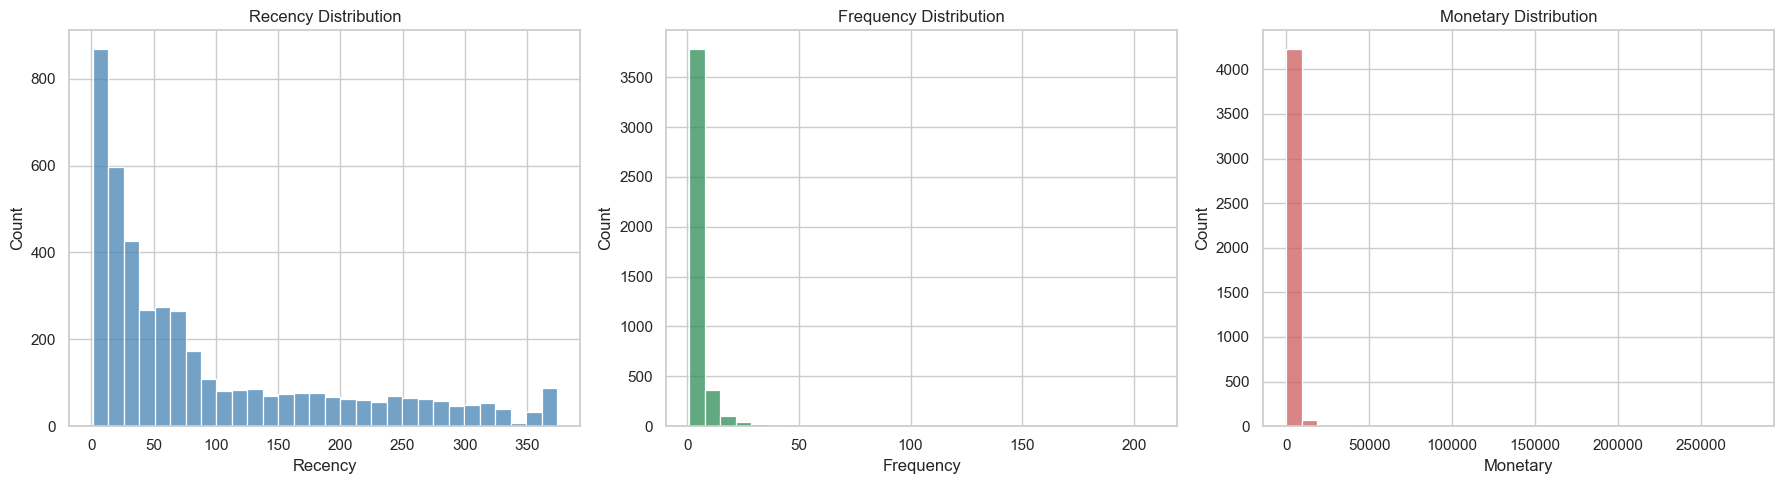

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(rfm["Recency"], bins=30, ax=axes[0], color="steelblue").set_title("Recency Distribution")
sns.histplot(rfm["Frequency"], bins=30, ax=axes[1], color="seagreen").set_title("Frequency Distribution")
sns.histplot(rfm["Monetary"], bins=30, ax=axes[2], color="indianred").set_title("Monetary Distribution")
plt.savefig("RFM_distribution.png")
plt.tight_layout()
plt.show()

## Feature Scaling
K-Means is distance-based, so features on different scales (Recency in days vs Monetary in thousands) must be standardized first.

In [12]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[["Recency", "Frequency", "Monetary"]])
rfm_scaled = pd.DataFrame(rfm_scaled, columns=["Recency", "Frequency", "Monetary"])
rfm_scaled.head()

,Recency,Frequency,Monetary
0,2.334574,-0.425097,8.363010
1,-0.905340,0.354417,0.251699
2,-0.175360,-0.035340,-0.027988
3,-0.735345,-0.425097,-0.032406
4,2.174578,-0.425097,-0.190812


## Finding Optimal K — Elbow Method

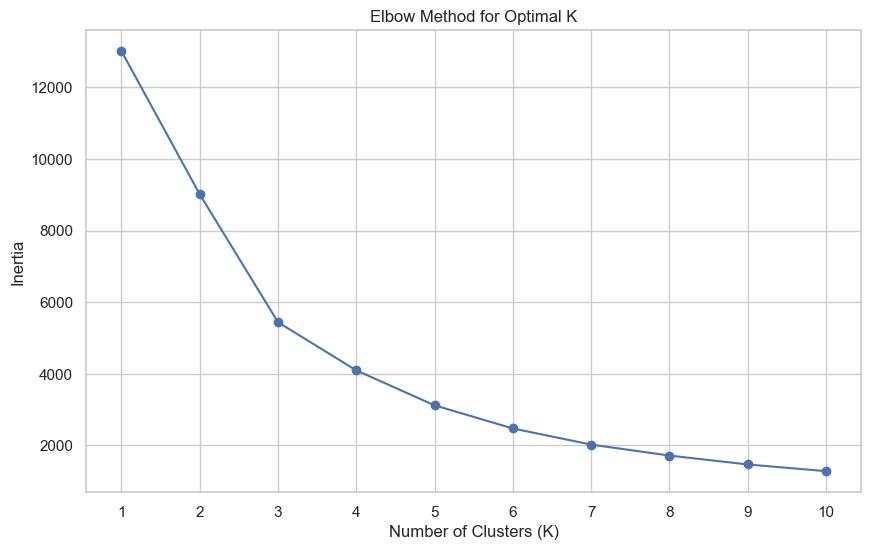

In [19]:
inertia = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)

plt.plot(K_range, inertia, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.savefig("elbow_method.png")
plt.xticks(K_range)
plt.show()

## Applying K-Means
Based on the elbow plot above, pick the K where the curve starts to flatten (commonly 4 for RFM datasets — adjust based on what you see).

In [15]:
optimal_k = 4  # <-- change this based on your elbow plot

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346,326,1,77183.60,3
1,12347,2,7,4310.00,0
2,12348,75,4,1797.24,0
3,12349,19,1,1757.55,0
4,12350,310,1,334.40,1


## Visualizing Clusters

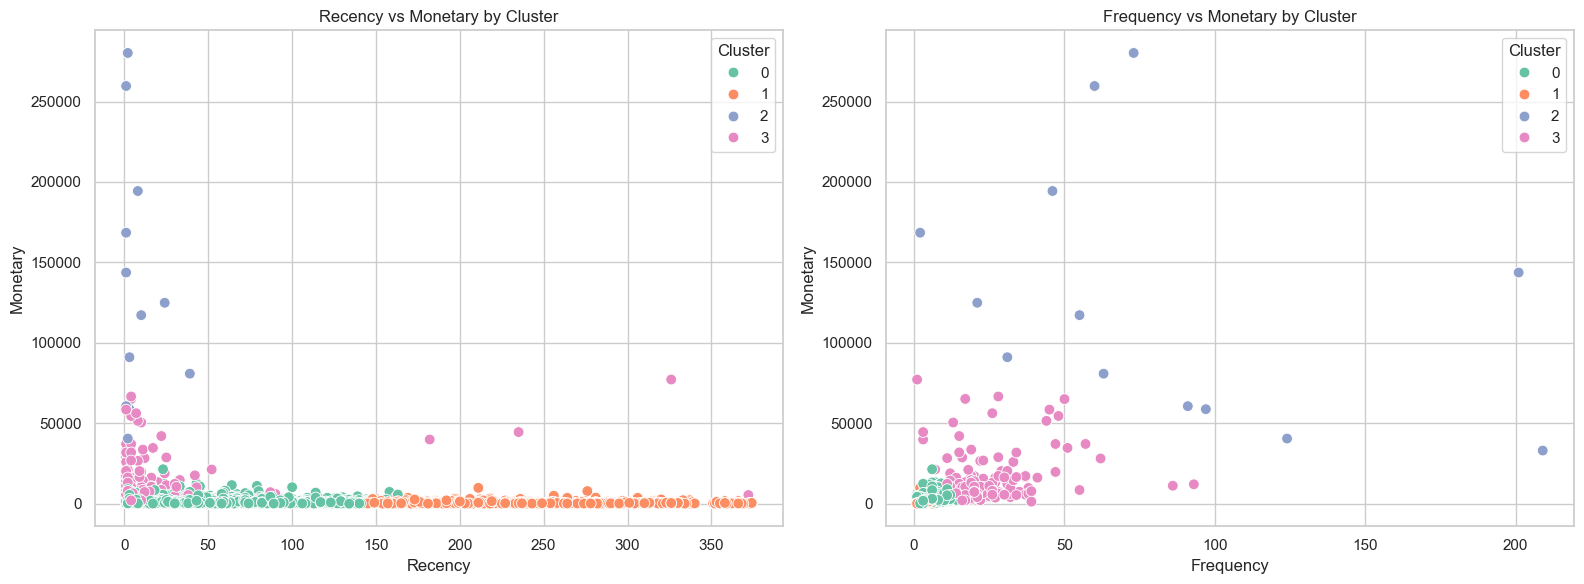

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(data=rfm, x="Recency", y="Monetary", hue="Cluster", palette="Set2", ax=axes[0], s=60)
axes[0].set_title("Recency vs Monetary by Cluster")

sns.scatterplot(data=rfm, x="Frequency", y="Monetary", hue="Cluster", palette="Set2", ax=axes[1], s=60)
axes[1].set_title("Frequency vs Monetary by Cluster")
plt.savefig("cluster.png")
plt.tight_layout()
plt.show()

## Cluster Profiling

In [17]:
cluster_profile = rfm.groupby("Cluster").agg(
    Avg_Recency=("Recency", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_Monetary=("Monetary", "mean"),
    Num_Customers=("CustomerID", "count")
).round(1)

cluster_profile

,Avg_Recency,Avg_Frequency,Avg_Monetary,Num_Customers
Cluster,,,,
0,43.7,3.7,1353.6,3054
1,248.1,1.6,478.8,1067
2,7.4,82.5,127188.0,13
3,15.5,22.3,12690.5,204


C:\Users\shrey\AppData\Local\Temp\ipykernel_18672\1042393099.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=rfm, x="Cluster", palette="Set2")


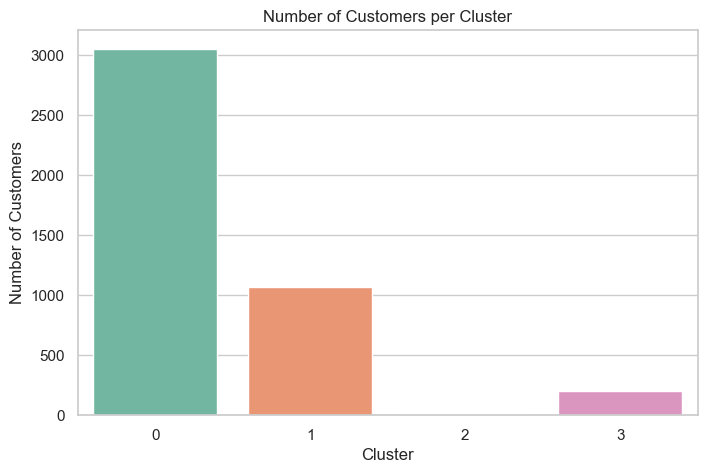

In [22]:
plt.figure(figsize=(8, 5))
sns.countplot(data=rfm, x="Cluster", palette="Set2")
plt.title("Number of Customers per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.savefig("customer_per_cluster.png")
plt.show()

## Insights & Marketing Recommendations

Based on the cluster profile table above, label each cluster and suggest an action. Example pattern (replace with your real numbers):

- **Cluster 0 — "Champions"** (low Recency, high Frequency, high Monetary): Your best customers. → Reward with loyalty perks, early access to new products, referral incentives.
- **Cluster 1 — "At Risk"** (high Recency, moderate past Frequency/Monetary): Used to buy often but have gone quiet. → Send win-back emails, personalized discounts.
- **Cluster 2 — "New/Low-Value"** (low Frequency, low Monetary): Infrequent, small purchases. → Onboarding campaigns, bundle offers to increase basket size.
- **Cluster 3 — "Steady Regulars"** (moderate on all metrics): Reliable but not high-spending. → Upsell/cross-sell campaigns to increase order value.